# Aplicação estratégica — alfabetização no Brasil

**Tech Challenge Fase 3** · Pós-Tech FIAP AI Scientist

Este notebook responde as cinco perguntas de negócio do enunciado usando os artefatos
produzidos pelo pipeline. Ele **não recalcula nada** — lê `reports/` — para que nunca
discorde dos relatórios técnicos.

| Pergunta | Onde é respondida |
|---|---|
| Quais fatores mais impactam a alfabetização? | §2 — SHAP |
| Quais variáveis têm maior influência no modelo? | §2 — SHAP |
| Quais municípios apresentam maior risco educacional? | §3 — ranking |
| Como prever municípios que podem não atingir metas? | §4 — gap contra meta |
| Quais regiões possuem padrões semelhantes? | §5 — clusterização |

> O foco não é a métrica, é a decisão que ela habilita.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

REPORTS = Path("..") / "reports"

def carregar_json(nome):
    return json.loads((REPORTS / nome).read_text(encoding="utf-8"))

resultado = carregar_json("resultado_final.json")
interpretacao = carregar_json("interpretabilidade.json")
risco = carregar_json("risco_municipal.json")
clusters = carregar_json("clusterizacao.json")

ranking = pd.read_csv(REPORTS / "ranking_risco_municipal.csv", dtype={"id_municipio": str})
shap_imp = pd.read_csv(REPORTS / "shap_importancia.csv")
print("artefatos carregados")

artefatos carregados


## 1. O que o modelo faz — e em que nível ele é confiável

O modelo prevê, para cada aluno avaliado em 2024, a probabilidade de ser considerado
alfabetizado, usando **apenas informação anterior à avaliação**: histórico municipal de
2023, metas pactuadas e contexto socioeconômico.

Há uma assimetria fundamental no resultado, e ela define todo o uso prático.

In [2]:
teste = resultado["teste"]
base = resultado["baseline_municipal"]

comparacao = pd.DataFrame({"modelo": teste, "baseline municipal": base}).round(4)
print("DESEMPENHO POR ALUNO (conjunto de teste, aberto uma unica vez)")
print(comparacao.to_string())

print()
print("DESEMPENHO POR MUNICIPIO (mesmos dados, agregados)")
v = risco["validacao_ranking"]
print(f"  correlacao de ordem (Spearman) previsto x observado : {v['correlacao_spearman']:.3f}")
print(f"  mesmo calculo usando so a taxa de 2023 (baseline)   : {v['baseline_spearman_taxa_2023']:.3f}")
print(f"  separacao entre decil de maior e menor risco        : {v['separacao_pp']:.1f} p.p.")

DESEMPENHO POR ALUNO (conjunto de teste, aberto uma unica vez)
                modelo  baseline municipal
auc_roc         0.6633              0.6371
auc_pr_risco    0.5488              0.5234
f1              0.7376              0.7137
f1_risco        0.4276              0.4463
precisao_risco  0.5871              0.5395
recall_risco    0.3362              0.3806
acuracia        0.6402              0.6226
brier           0.2207              0.2280

DESEMPENHO POR MUNICIPIO (mesmos dados, agregados)
  correlacao de ordem (Spearman) previsto x observado : 0.778
  mesmo calculo usando so a taxa de 2023 (baseline)   : 0.624
  separacao entre decil de maior e menor risco        : 48.3 p.p.


**Por que a diferença entre os dois níveis.**

Os microdados são anonimizados sob LGPD e não trazem nenhum atributo do aluno — nem sexo,
nem idade, nem condição socioeconômica. Todas as features são **municipais**. Dois alunos
do mesmo município e da mesma rede são, para o modelo, idênticos.

Isso impõe um teto à predição individual: o modelo não pode distinguir crianças dentro de
um município porque não recebe nada que as distinga. O que ele faz bem é ordenar
**municípios**, e é nesse nível que a política pública opera — orçamento, apoio técnico e
formação de professores são alocados por rede, não por criança.

Ler a AUC por aluno como "modelo fraco" seria interpretar errado a ferramenta.

## 2. Quais fatores mais impactam a alfabetização

Valores SHAP sobre o modelo final. A medida é quanto cada variável desloca a previsão, em
log-odds; a direção indica se valores altos empurram para alfabetizado (+) ou contra (−).

                     feature  shap_medio_abs  direcao         direcao_texto
     hist_proficiencia_media          0.1800   0.9811 aumenta alfabetizacao
     hist_taxa_alfabetizacao          0.1402   0.9036 aumenta alfabetizacao
      hist_taxa_participacao          0.0586   0.9021 aumenta alfabetizacao
                       uf_RS          0.0548  -0.9885   reduz alfabetizacao
     meta_alfabetizacao_2026          0.0502   0.9634 aumenta alfabetizacao
                       uf_MG          0.0389   0.9650 aumenta alfabetizacao
                       uf_BA          0.0325  -0.9813   reduz alfabetizacao
                      rede_3          0.0265  -0.9043   reduz alfabetizacao
                      rede_2          0.0243   0.9263 aumenta alfabetizacao
              regiao_Sudeste          0.0236   0.8826 aumenta alfabetizacao
taxa_agua_esgoto_inadequados          0.0206  -0.5603   reduz alfabetizacao
               gap_meta_2024          0.0174  -0.9064   reduz alfabetizacao
            

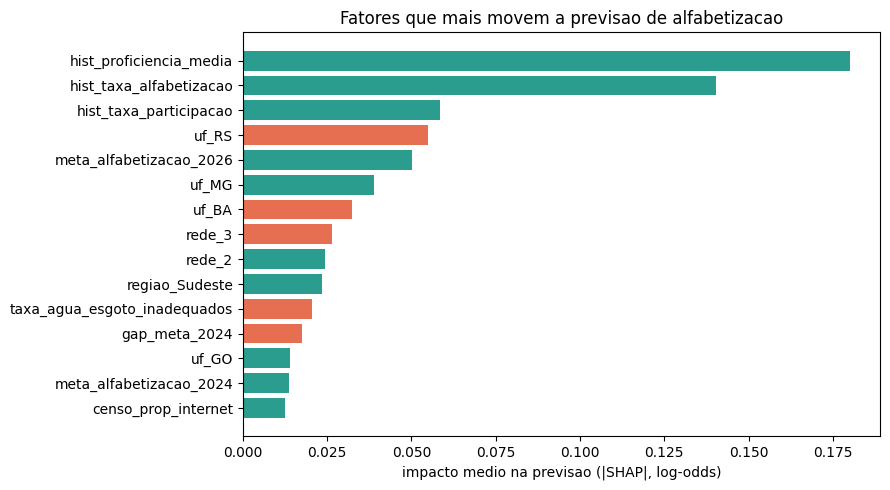

In [3]:
top = shap_imp.head(15).copy()
top["direcao_texto"] = top["direcao"].apply(
    lambda d: "aumenta alfabetizacao" if d > 0 else "reduz alfabetizacao"
)
print(top[["feature", "shap_medio_abs", "direcao", "direcao_texto"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#2a9d8f" if d > 0 else "#e76f51" for d in top["direcao"]]
ax.barh(top["feature"][::-1], top["shap_medio_abs"][::-1], color=cores[::-1])
ax.set_xlabel("impacto medio na previsao (|SHAP|, log-odds)")
ax.set_title("Fatores que mais movem a previsao de alfabetizacao")
plt.tight_layout(); plt.show()

### Leitura crítica: importância não é causalidade, e correlação divide crédito

Duas ressalvas que mudam a interpretação:

1. **As variáveis de topo são fortemente correlacionadas entre si.** A meta pactuada de um
   município correlaciona 0,947 com sua taxa histórica — a meta é, na prática, uma
   reformulação do nível atual. O SHAP divide o crédito entre variáveis correlacionadas, então
   elas devem ser lidas como **um único sinal**: "o nível educacional prévio do município".

2. **O modelo mede associação, não causa.** Que infraestrutura escolar apareça associada a
   melhor alfabetização não autoriza concluir que construir bibliotecas alfabetiza. Municípios
   com biblioteca têm também mais orçamento, mais formação docente e menos pobreza.

O uso legítimo é **priorização** — onde olhar primeiro —, não atribuição de causa.

## 3. Quais municípios apresentam maior risco educacional

O ranking cobre todos os municípios da base. A validação usa **somente municípios de teste**,
que não participaram do treino em nenhuma etapa.

VALIDACAO (municipios que o modelo nunca viu)
  Spearman previsto x observado : 0.778
  taxa real no decil de MAIOR risco : 36.3%
  taxa real no decil de MENOR risco : 84.5%



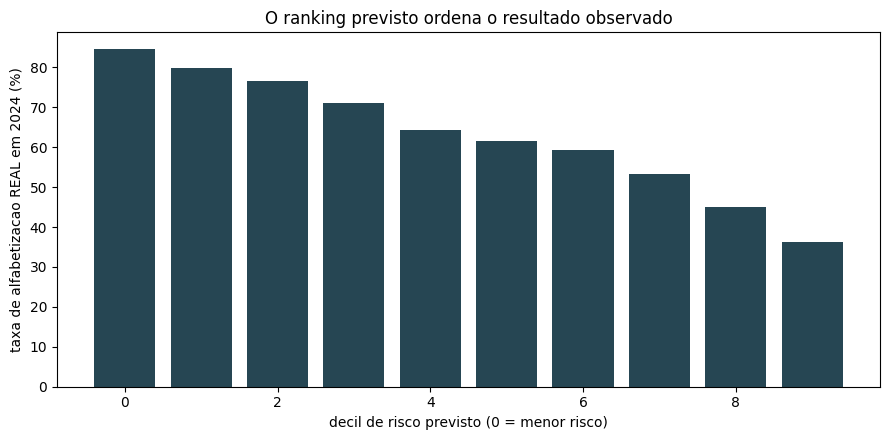

In [4]:
v = risco["validacao_ranking"]
print("VALIDACAO (municipios que o modelo nunca viu)")
print(f"  Spearman previsto x observado : {v['correlacao_spearman']:.3f}")
print(f"  taxa real no decil de MAIOR risco : {v['taxa_observada_decil_maior_risco']:.1%}")
print(f"  taxa real no decil de MENOR risco : {v['taxa_observada_decil_menor_risco']:.1%}")
print()

decis = pd.DataFrame(v["por_decil"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(decis["decil_risco"], decis["taxa_observada"] * 100, color="#264653")
ax.set_xlabel("decil de risco previsto (0 = menor risco)")
ax.set_ylabel("taxa de alfabetizacao REAL em 2024 (%)")
ax.set_title("O ranking previsto ordena o resultado observado")
plt.tight_layout(); plt.show()

In [5]:
print("TOP 20 MUNICIPIOS EM RISCO")
colunas = ["posicao_risco", "id_municipio", "uf", "n_alunos", "taxa_prevista",
           "gap_meta_2024", "situacao_historico"]
print(ranking.head(20)[colunas].round(3).to_string(index=False))

TOP 20 MUNICIPIOS EM RISCO
 posicao_risco id_municipio uf  n_alunos  taxa_prevista  gap_meta_2024 situacao_historico
             1      2901908 BA       230          0.221         -2.583           completo
             2      2907202 BA       430          0.232          3.800           completo
             3      2902252 BA        61          0.241          0.414           completo
             4      2910503 BA       255          0.252            NaN           completo
             5      2919900 BA        40          0.258         17.362           completo
             6      2917003 BA       247          0.258         -9.191           completo
             7      2924405 BA       391          0.260         -5.138           completo
             8      2902104 BA       331          0.262         -1.160           completo
             9      2924207 BA       132          0.267         -9.545           completo
            10      2932457 BA       122          0.267         -1.726   

**Como esta lista deve ser usada.** Ela prioriza, não condena. Um município no topo do
ranking é um município onde o contexto prévio indica dificuldade — o que justifica **olhar
primeiro**, não punir. A coluna `situacao_historico` informa a qualidade da evidência:
`completo` tem histórico derivado do microdado, `parcial` só a taxa agregada, `ausente` é
cold start e a previsão ali é a menos confiável.

## 4. Municípios que podem não atingir as metas

O Compromisso Nacional Criança Alfabetizada fixa metas por município. Comparando a taxa
prevista com a meta pactuada, obtém-se quem está fora de rota.

**Limite honesto:** o modelo prevê 2024. O confronto com a meta de 2026 mede a distância
**atual** até aquela meta, assumindo estagnação — é alerta de rota, não previsão temporal.

municipios em risco de perder a meta de 2024 : 2,136 (38.7%)
alunos nesses municipios                     : 797,017

      regiao  n_municipios  risco_medio  fracao_em_risco_de_meta
Centro-Oeste           466       0.2845                   0.1052
    Nordeste          1782       0.4333                   0.4226
       Norte           435       0.4909                   0.4920
     Sudeste          1664       0.2972                   0.2091
         Sul          1170       0.3565                   0.6598


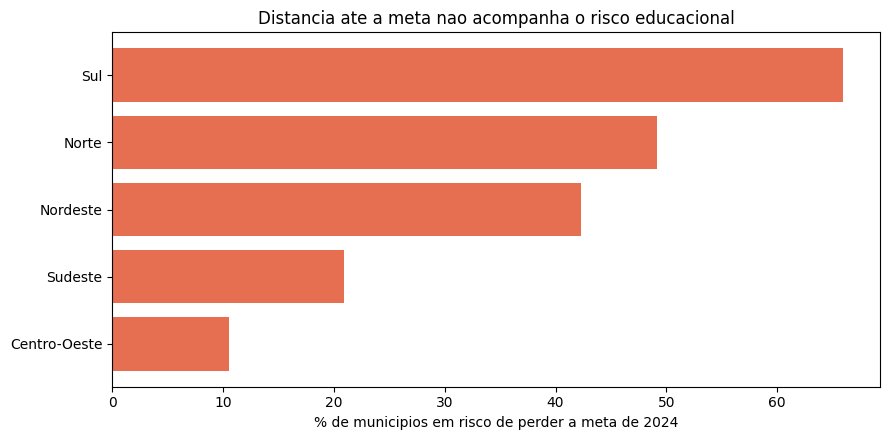

In [6]:
meta = risco["meta_2024"]
print(f"municipios em risco de perder a meta de 2024 : {meta['municipios_em_risco']:,} "
      f"({meta['fracao']:.1%})")
print(f"alunos nesses municipios                     : {meta['alunos_afetados']:,}")
print()

por_regiao = pd.DataFrame(risco["por_regiao"])
print(por_regiao.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ordem = por_regiao.sort_values("fracao_em_risco_de_meta")
ax.barh(ordem["regiao"], ordem["fracao_em_risco_de_meta"] * 100, color="#e76f51")
ax.set_xlabel("% de municipios em risco de perder a meta de 2024")
ax.set_title("Distancia ate a meta nao acompanha o risco educacional")
plt.tight_layout(); plt.show()

### O achado contraintuitivo desta seção

A fração de municípios em risco de perder a meta **não segue** o ranking de risco
educacional. Regiões com melhor desempenho absoluto podem ter mais municípios fora de rota,
porque suas metas foram pactuadas em patamar mais ambicioso.

São dois indicadores distintos, e confundi-los leva a decisão errada:

- **risco educacional** — onde as crianças têm menos chance de se alfabetizar
- **risco de meta** — onde o compromisso pactuado está mais distante do resultado esperado

Um município pode ir bem e ainda assim perder a meta; outro pode ir mal e cumprir a sua.
Apoio técnico segue o primeiro indicador; repactuação de metas, o segundo.

## 5. Quais regiões possuem padrões semelhantes

Agrupamento não supervisionado (K-Means) sobre o perfil socioeconômico, de infraestrutura e
de desempenho histórico dos municípios — sem usar o resultado de 2024.

In [7]:
print(f"silhueta maxima encontrada : {clusters['silhueta_maxima']:.3f}")
print(f"estrutura de grupos forte  : {clusters['estrutura_de_grupos_forte']}")
print(f"k pela silhueta            : {clusters['k_pela_silhueta']}")
print(f"k operacional adotado      : {clusters['k_operacional']}")
print()
print(pd.DataFrame(clusters["diagnostico"]).round(4).to_string(index=False))

silhueta maxima encontrada : 0.283
estrutura de grupos forte  : False
k pela silhueta            : 2
k operacional adotado      : 4

 k  silhueta    inercia
 2    0.2833 95556.4904
 3    0.1722 87005.7052
 4    0.1771 80606.1975
 5    0.1300 76844.3142
 6    0.1697 74251.6700
 7    0.1231 70683.9998
 8    0.1114 68548.5304


**A ausência de estrutura é, ela própria, o achado.** Todas as silhuetas ficaram abaixo de
0,30 — os municípios brasileiros **não formam grupos discretos**, formam um contínuo de
desenvolvimento. O k=2 que a silhueta aponta apenas recupera a divisão regional já conhecida.

Por isso adotamos uma **segmentação operacional** em 4 faixas: ela não descobre grupos
naturais, ela particiona o contínuo em faixas úteis para direcionar política. A distinção
está declarada, não escondida — apresentar o k=4 como "grupos descobertos nos dados" seria
sobrevender o resultado.

In [8]:
caract = pd.read_csv(REPORTS / "segmentos_caracteristicas.csv", index_col=0)
destaque = caract.T.reindex(caract.abs().max().sort_values(ascending=False).index).head(10)
print("O QUE DISTINGUE CADA SEGMENTO (desvio relativo a media nacional)")
print(destaque.round(3).to_string())

cruz = clusters.get("cruzamento_com_risco")
if cruz:
    print()
    print("RISCO EDUCACIONAL POR SEGMENTO")
    print(pd.DataFrame(cruz).round(4).to_string(index=False))

O QUE DISTINGUE CADA SEGMENTO (desvio relativo a media nacional)
segmento                            0      1      2      3
taxa_agua_esgoto_inadequados   -0.714 -0.839  2.959  0.825
taxa_criancas_fora_escola_6_14 -0.192 -0.217  2.016  0.034
populacao                      -0.757  1.674 -0.343 -0.525
prop_pobreza                   -0.450 -0.708  1.219  0.750
censo_prop_rural               -0.219 -0.654  1.079  0.525
part_va_industria              -0.298  0.889 -0.547 -0.317
prop_pobreza_criancas          -0.352 -0.631  0.870  0.657
censo_prop_biblioteca           0.399  0.206 -0.764 -0.397
part_va_agropecuaria            0.669 -0.552  0.155 -0.209
taxa_analfabetismo_15_mais     -0.311 -0.555  0.514  0.617

RISCO EDUCACIONAL POR SEGMENTO
 segmento  n_municipios  risco_previsto  taxa_observada  fracao_em_risco_de_meta
        0          1767          0.3055          0.6984                   0.3650
        1          1479          0.3526          0.6488                   0.4151
        2  

## 6. Recomendações

1. **Usar o modelo como priorizador municipal, não como classificador de crianças.** É no
   nível municipal que ele demonstra capacidade de ordenação, e é nele que o orçamento é
   alocado. Rotular uma criança individualmente com este modelo seria usar a ferramenta fora
   da sua validade demonstrada.

2. **Ajustar o corte à capacidade do programa.** O limiar de decisão é parâmetro de gestão,
   não de modelagem, e muda sem retreinar: um programa que atende 30% da rede opera num
   corte; um que atende metade opera em outro e alcança mais crianças, com menos precisão.
   A tabela completa está em `reports/analise_threshold.csv`.

3. **Separar risco educacional de risco de meta.** São indicadores diferentes e pedem
   respostas diferentes — apoio pedagógico num caso, repactuação no outro.

4. **Publicar um identificador de escola pseudonimizado porém estável.** Hoje o `id_escola`
   é re-sorteado a cada ano, o que impede qualquer análise longitudinal de escola. Medimos
   que 17,7% da variação do resultado está *entre escolas do mesmo município* — é sinal real,
   hoje inalcançável. Um ID estável (sem reidentificar ninguém) destravaria essa camada
   inteira de política.

5. **Completar a cobertura do microdado.** São Paulo não tem microdado de 2023 na base
   pública, o que deixa 21% dos alunos com histórico apenas parcial. É a maior lacuna de
   dado do projeto e a de correção mais barata.

## 7. Limitações

| Limitação | Consequência |
|---|---|
| Sem atributos individuais do aluno (LGPD) | Teto estrutural na predição individual |
| `id_escola` re-sorteado anualmente | Impossível usar histórico de escola |
| SP sem microdado de 2023 | 21% dos alunos com histórico parcial |
| Cold start real (1,9%) | Previsão menos confiável em DF, AC e casos isolados |
| Modelo treinado em um único par de anos (2023→2024) | Não capturado: efeito de mudanças de política ao longo do tempo |
| Associação, não causalidade | Não autoriza concluir que intervir numa variável muda o resultado |

Nenhuma delas invalida o uso proposto — priorização municipal. Todas delimitam o que o
modelo **não** pode sustentar.